# Spotify Data Engineering Project - User Stories Analysis

## Projektziel
Analyse von Spotify-Daten zur Umsetzung von drei Haupt-User Stories:
1. **Monatliche Streaming-Statistiken** - Bestimmung der Abo-Rentabilität
2. **Playlist-Vergleich** - Analyse der Unterschiede zwischen benutzererstellten und systemgenerierten Playlists
3. **Wöchentliche Aktivität** - Histogramm der Aktivität und Analyse beliebter Tracks

## Schritt 1: Verbindung zur Spotify API


In [192]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import warnings
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import os
from dotenv import load_dotenv

# Suppress warnings
warnings.filterwarnings('ignore')

print("Bibliotheken erfolgreich importiert")


Bibliotheken erfolgreich importiert


In [193]:
def init_spotify():
    """Initialize connection to Spotify API"""
    load_dotenv()
    
    client_id = os.getenv("SPOTIFY_CLIENT_ID")
    client_secret = os.getenv("SPOTIFY_CLIENT_SECRET")
    redirect_uri = os.getenv("SPOTIFY_REDIRECT_URI")
    
    if not all([client_id, client_secret, redirect_uri]):
        raise ValueError("Spotify-Anmeldedaten fehlen in der .env-Datei")
    
    sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
        client_id=client_id,
        client_secret=client_secret,
        redirect_uri=redirect_uri,
        scope="user-read-recently-played user-read-private user-read-email playlist-read-private user-top-read"
    ))
    
    return sp

print("Spotify-Initialisierungsfunktion erstellt")


Spotify-Initialisierungsfunktion erstellt


In [194]:
# Test Spotify API connection
try:
    sp = init_spotify()
    user_info = sp.current_user()
    
    print("Spotify API-Verbindung erfolgreich")
    print(f"Verbunden als: {user_info.get('display_name', 'Unbekannt')}")
    print(f"Benutzer-ID: {user_info['id']}")
    print(f"E-Mail: {user_info.get('email', 'Nicht verfügbar')}")
    print(f"Land: {user_info.get('country', 'Nicht verfügbar')}")
    print(f"Follower: {user_info.get('followers', {}).get('total', 0)}")
    
    # Test API functionality
    recent_tracks = sp.current_user_recently_played(limit=1)
    if recent_tracks['items']:
        print("Zugriff auf kürzlich gespielte Tracks: Funktioniert")
    else:
        print("Zugriff auf kürzlich gespielte Tracks: Keine kürzlich gespielten Tracks gefunden")
    
    playlists = sp.current_user_playlists(limit=1)
    if playlists['items']:
        print("Zugriff auf Playlists: Funktioniert")
    else:
        print("Zugriff auf Playlists: Keine Playlists gefunden")
    
    print("\nSpotify API ist vollständig funktionsfähig und bereit für die Datensammlung")
    
except Exception as e:
    print(f"Fehler bei der Verbindung zur Spotify API: {e}")
    sp = None


Spotify API-Verbindung erfolgreich
Verbunden als: Vadim
Benutzer-ID: 317fd22v4rytxoc6x6o4pi3ixpze
E-Mail: vclash009@gmail.com
Land: AT
Follower: 0
Zugriff auf kürzlich gespielte Tracks: Funktioniert
Zugriff auf Playlists: Funktioniert

Spotify API ist vollständig funktionsfähig und bereit für die Datensammlung


## Schritt 2: User Story 1 - Monatliche Streaming-Statistiken

**User Story:** Als User will ich meine gestreamten Stunden im aktuellen Monat wissen, um zu prüfen, ob sich das Abo überhaupt lohnt.

**Ziel:** DataFrame mit monatlichen Streaming-Daten erstellen und Abo-Rentabilität analysieren.


In [195]:
def collect_monthly_streaming_data(sp, user_id):
    """Collect monthly streaming data for subscription analysis"""
    if not sp:
        print("Keine Spotify-Verbindung verfügbar")
        return pd.DataFrame()
    
    print("Sammle monatliche Streaming-Daten...")
    
    # Get current month data
    current_month = datetime.datetime.now().strftime("%Y-%m")
    
    # Collect ALL recently played tracks for the month (no limit)
    try:
        monthly_data = []
        total_duration_ms = 0
        track_count = 0
        
        # Get all recent tracks (Spotify API allows up to 50 per request, so we paginate)
        after = None
        while True:
            if after:
                recent_tracks = sp.current_user_recently_played(limit=50, after=after)
            else:
                recent_tracks = sp.current_user_recently_played(limit=50)
            
            if not recent_tracks['items']:
                break
                
            for item in recent_tracks['items']:
                track = item['track']
                played_at = item['played_at']
                
                # Check if track is from current month
                track_month = played_at[:7]  # YYYY-MM format
                if track_month == current_month:
                    track_data = {
                        'track_id': track['id'],
                        'track_name': track['name'],
                        'artists': [artist['name'] for artist in track['artists']],
                        'album_name': track['album']['name'],
                        'duration_ms': track['duration_ms'],
                        'played_at': played_at,
                        'popularity': track['popularity'],
                        'explicit': track['explicit']
                    }
                    monthly_data.append(track_data)
                    total_duration_ms += track['duration_ms']
                    track_count += 1
                else:
                    # If we hit tracks from previous month, stop collecting
                    break
            
            # Check if we should continue pagination
            if len(recent_tracks['items']) < 50:
                break
                
            # Get the timestamp of the last track for pagination
            last_track = recent_tracks['items'][-1]
            after = last_track['played_at']
            
            # Stop if we've gone too far back (more than 1 month)
            last_track_month = last_track['played_at'][:7]
            if last_track_month != current_month:
                break
        
        # Calculate monthly statistics
        total_hours = total_duration_ms / (1000 * 60 * 60)
        avg_track_duration = total_duration_ms / track_count if track_count > 0 else 0
        
        # Subscription cost analysis (Spotify Premium ~10 EUR/month)
        subscription_cost = 10.0
        cost_per_hour = subscription_cost / total_hours if total_hours > 0 else 0
        
        monthly_stats = {
            'month': current_month,
            'total_tracks': track_count,
            'total_hours': round(total_hours, 2),
            'avg_track_duration_minutes': round(avg_track_duration / (1000 * 60), 2),
            'subscription_cost_eur': subscription_cost,
            'cost_per_hour_eur': round(cost_per_hour, 2),
            'is_worthwhile': cost_per_hour < 1.0  # Worthwhile if less than 1 EUR per hour
        }
        
        print(f"Monatliche Daten gesammelt für {current_month}")
        print(f"Gesamte Tracks: {track_count}")
        print(f"Gesamte Stunden: {total_hours:.2f}")
        print(f"Kosten pro Stunde: {cost_per_hour:.2f} EUR")
        
        return pd.DataFrame(monthly_data), monthly_stats
        
    except Exception as e:
        print(f"Fehler beim Sammeln der monatlichen Daten: {e}")
        return pd.DataFrame(), {}

print("Funktion zur Sammlung monatlicher Streaming-Daten erstellt")


Funktion zur Sammlung monatlicher Streaming-Daten erstellt


In [196]:
from IPython.display import display  

# ...

if sp:
    monthly_df, monthly_stats = collect_monthly_streaming_data(sp, user_info['id'])
    
    if not monthly_df.empty:
        print("\n=== MONATLICHE STREAMING-DATEN ===")
        print(f"Monat: {monthly_stats['month']}")
        print(f"Gesamte Tracks: {monthly_stats['total_tracks']}")
        print(f"Gesamte Stunden: {monthly_stats['total_hours']}")
        print(f"Durchschnittliche Track-Dauer: {monthly_stats['avg_track_duration_minutes']} Minuten")
        print(f"Abonnement-Kosten: {monthly_stats['subscription_cost_eur']} EUR")
        print(f"Kosten pro Stunde: {monthly_stats['cost_per_hour_eur']} EUR")
        print(f"Lohnt sich das Abo: {'Ja' if monthly_stats['is_worthwhile'] else 'Nein'}")
        
        print("\n=== DATAFRAME STRUKTUR ===")
        print(f"DataFrame Shape: {monthly_df.shape}")
        print(f"Spalten: {list(monthly_df.columns)}")
        
        # Prepare DataFrame for better display
        display_df = monthly_df.copy()
        
        # Convert duration to minutes for better readability
        display_df['duration_minutes'] = (display_df['duration_ms'] / (1000 * 60)).round(2)
        
        # Convert played_at to readable datetime
        display_df['played_at'] = pd.to_datetime(display_df['played_at'])
        display_df['played_at_formatted'] = display_df['played_at'].dt.strftime('%Y-%m-%d %H:%M')
        
        # Convert artists list to string for display
        display_df['artists_str'] = display_df['artists'].apply(lambda x: ', '.join(x))
        
        # Select and rename columns for display
        display_columns = {
            'track_name': 'Track Name',
            'artists_str': 'Artists', 
            'album_name': 'Album',
            'duration_minutes': 'Duration (min)',
            'played_at_formatted': 'Played At',
            'popularity': 'Popularity',
            'explicit': 'Explicit'
        }
        
        display_df_clean = display_df[list(display_columns.keys())].rename(columns=display_columns)
        
        print(f"\n=== ZUSAMMENFASSUNG ===")
        print(f"Gesamte Tracks im DataFrame: {len(monthly_df)}")
        print(f"Eindeutige Künstler: {monthly_df['artists'].explode().nunique()}")
        print(f"Eindeutige Alben: {monthly_df['album_name'].nunique()}")
        print(f"Durchschnittliche Popularität: {monthly_df['popularity'].mean():.1f}")
        print(f"Explicit Tracks: {monthly_df['explicit'].sum()}")
        

        display(display_df_clean)   
        
    else:
        print("Keine monatlichen Daten verfügbar")
        monthly_df = pd.DataFrame()
        monthly_stats = {}
else:
    print("Spotify-Verbindung nicht verfügbar")
    monthly_df = pd.DataFrame()
    monthly_stats = {}


Sammle monatliche Streaming-Daten...
Monatliche Daten gesammelt für 2025-09
Gesamte Tracks: 99
Gesamte Stunden: 4.17
Kosten pro Stunde: 2.40 EUR

=== MONATLICHE STREAMING-DATEN ===
Monat: 2025-09
Gesamte Tracks: 99
Gesamte Stunden: 4.17
Durchschnittliche Track-Dauer: 2.53 Minuten
Abonnement-Kosten: 10.0 EUR
Kosten pro Stunde: 2.4 EUR
Lohnt sich das Abo: Nein

=== DATAFRAME STRUKTUR ===
DataFrame Shape: (99, 8)
Spalten: ['track_id', 'track_name', 'artists', 'album_name', 'duration_ms', 'played_at', 'popularity', 'explicit']

=== ZUSAMMENFASSUNG ===
Gesamte Tracks im DataFrame: 99
Eindeutige Künstler: 22
Eindeutige Alben: 22
Durchschnittliche Popularität: 37.9
Explicit Tracks: 89


,Track Name,Artists,Album,Duration (min),Played At,Popularity,Explicit
0,THE_EVIL_THAT_MEN_DO,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.89,2025-09-25 00:55,54,True
1,Fucking Your Culture,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.27,2025-09-25 00:51,66,True
2,Eulogy,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.79,2025-09-25 00:48,57,True
3,Genesis,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.70,2025-09-25 00:43,63,True
4,МИКРОВОЛНОВКА ФЛОУ,SODA LUV,НИЧЕГО ЛИЧНОГО 2 (DELUXE),1.33,2025-09-25 00:36,13,True
...,...,...,...,...,...,...,...
94,МОШПИТ,"uglystephan, Платина",Goth Angel,2.17,2025-09-20 20:19,23,True
95,PTSD,Nemzzz,DO NOT DISTURB (DELUXE),2.15,2025-09-20 15:51,70,True
96,ASTROTHUNDER,Travis Scott,ASTROWORLD,2.38,2025-09-20 15:48,78,True
97,Château Gris,$uicideboy$,YIN YANG TAPES: Spring Season (1989-1990),3.39,2025-09-20 15:46,53,True


## Wie berechnen wir, ob sich das Abo lohnt?

**Formel:**
```
Kosten pro Stunde = Abo-Preis ÷ Gehörte Stunden
```

**Regel:**
- **Weniger als 1€ pro Stunde** = Abo lohnt sich 
- **Mehr als 1€ pro Stunde** = Abo lohnt sich nicht 

**Break-Even:** Bei 10 Stunden pro Monat = genau 1€ pro Stunde


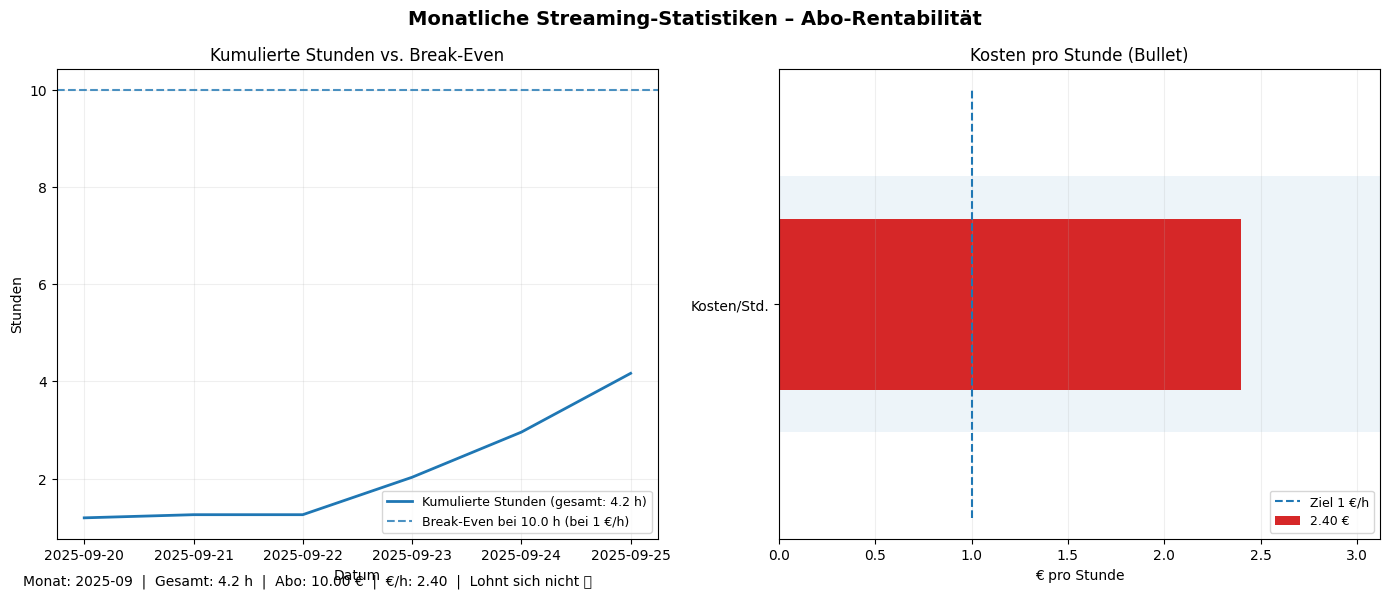

In [ ]:
# параметры
threshold_eur_per_hour = 1.0 

# подготовка данных
df = monthly_df.copy()
df['played_at'] = pd.to_datetime(df['played_at'])
df['hours'] = df['duration_ms'] / (1000*60*60)
daily = (df
         .set_index('played_at')
         .resample('D')['hours']
         .sum()
         .rename('hours_per_day')
         .to_frame()
         .reset_index())
daily['cum_hours'] = daily['hours_per_day'].cumsum()

total_hours = float(monthly_stats['total_hours'])
cost = float(monthly_stats['subscription_cost_eur'])
cph = float(monthly_stats['cost_per_hour_eur'])
break_even_hours = cost / threshold_eur_per_hour
worth = cph <= threshold_eur_per_hour

# фигура 1x2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Monatliche Streaming-Statistiken – Abo-Rentabilität', fontsize=14, fontweight='bold')

# (1) Накопленные часы vs break-even
ax = axes[0]
ax.plot(daily['played_at'], daily['cum_hours'], linewidth=2)
ax.axhline(break_even_hours, linestyle='--', alpha=0.8)
ax.set_title('Kumulierte Stunden vs. Break-Even')
ax.set_xlabel('Datum')
ax.set_ylabel('Stunden')
ax.grid(True, alpha=0.2)

# отметить день достижения break-even (если есть)
hit_idx = np.argmax(daily['cum_hours'].values >= break_even_hours)
if daily['cum_hours'].iloc[-1] >= break_even_hours:
    hit_date = daily['played_at'].iloc[hit_idx]
    ax.axvline(hit_date, linestyle=':', alpha=0.6)
    ax.annotate('Break-Even erreicht',
                xy=(hit_date, break_even_hours),
                xytext=(10, 10),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', lw=1),
                fontsize=9)

# легенда с фактическими значениями
ax.legend([f'Kumulierte Stunden (gesamt: {total_hours:.1f} h)',
           f'Break-Even bei {break_even_hours:.1f} h (bei {threshold_eur_per_hour:.0f} €/h)'],
          loc='lower right', fontsize=9)

# (2) Bullet chart «Kosten pro Stunde»
ax2 = axes[1]
max_x = max(threshold_eur_per_hour*1.6, cph*1.3, 1.5)
# фон-диапазон
ax2.barh(['Kosten/Std.'], [max_x], height=0.6, alpha=0.08)
# фактическое значение
ax2.barh(['Kosten/Std.'], [cph], height=0.4, label=f'{cph:.2f} €', color=('#2ca02c' if worth else '#d62728'))
# порог
ax2.vlines(threshold_eur_per_hour, -0.5, 0.5, linestyles='--', label=f'Ziel {threshold_eur_per_hour:.0f} €/h')
ax2.set_xlim(0, max_x)
ax2.set_title('Kosten pro Stunde (Bullet)')
ax2.set_xlabel('€ pro Stunde')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='x', alpha=0.2)

# KPI-тайлы текстом
fig.text(0.02, 0.02,
         f"Monat: {monthly_stats['month']}  |  Gesamt: {total_hours:.1f} h  |  Abo: {cost:.2f} €  |  €/h: {cph:.2f}  |  "
         f"{'Lohnt sich ' if worth else 'Lohnt sich nicht '}",
         fontsize=10)

plt.tight_layout()
plt.show()

In [198]:
if not monthly_df.empty:
    print(f"=== TOP 5 HÄUFIG GESPIELTE TRACKS ({monthly_stats['month']}) ===")

    track_play_counts = monthly_df['track_name'].value_counts().head(5)
    
    most_played_tracks = []
    for track_name in track_play_counts.index:
        track_info = monthly_df[monthly_df['track_name'] == track_name].iloc[0]
        most_played_tracks.append({
            'Track Name': track_name,
            'Artists': ', '.join(track_info['artists']),
            'Album': track_info['album_name'],
            'Plays': track_play_counts[track_name],
            'Duration (min)': round(track_info['duration_ms'] / (1000 * 60), 2),
            'Popularity': track_info['popularity']
        })
    
    most_played_df = pd.DataFrame(most_played_tracks)

    # Классическая таблица без подсветки
    display(most_played_df[['Track Name', 'Artists', 'Album', 'Plays', 'Duration (min)', 'Popularity']])


=== TOP 5 HÄUFIG GESPIELTE TRACKS (2025-09) ===


,Track Name,Artists,Album,Plays,Duration (min),Popularity
0,Звонок,SODA LUV,NATIVE STRANGERS,8,3.17,25
1,Челси 3,THRILL PILL,CHELSEA 3,4,1.28,24
2,ТЫ ВЫГЛЯДИШЬ,uglystephan,Goth Angel,4,1.80,21
3,не надо,MAYOT,ОБА,4,2.24,35
4,MAYBACH,SODA LUV,НИЧЕГО ЛИЧНОГО 2 (DELUXE),4,2.40,13


In [199]:
if not monthly_df.empty:
    print("=== TOP 5 NEUESTE TRACKS ===")
    
    # сортируем по дате прослушивания (последние сверху)
    latest_df = monthly_df.sort_values(by="played_at", ascending=False).head(5).copy()
    
    # делаем человеко-читаемый формат даты
    latest_df["played_at_formatted"] = pd.to_datetime(latest_df["played_at"]).dt.strftime("%Y-%m-%d %H:%M")
    latest_df["artists_str"] = latest_df["artists"].apply(lambda x: ", ".join(x))
    latest_df["duration_min"] = (latest_df["duration_ms"] / (1000 * 60)).round(2)

    # выбираем и переименовываем нужные колонки
    latest_display = latest_df[[
        "track_name", "artists_str", "album_name", "duration_min", "popularity", "played_at_formatted"
    ]].rename(columns={
        "track_name": "Track Name",
        "artists_str": "Artists",
        "album_name": "Album",
        "duration_min": "Duration (min)",
        "popularity": "Popularity",
        "played_at_formatted": "Played At"
    })

    display(latest_display)  # для Jupyter / VSCode


=== TOP 5 NEUESTE TRACKS ===


,Track Name,Artists,Album,Duration (min),Popularity,Played At
0,THE_EVIL_THAT_MEN_DO,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.89,54,2025-09-25 00:55
50,THE_EVIL_THAT_MEN_DO,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.89,54,2025-09-25 00:55
1,Fucking Your Culture,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.27,66,2025-09-25 00:51
51,Fucking Your Culture,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.27,66,2025-09-25 00:51
2,Eulogy,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.79,57,2025-09-25 00:48


## Schritt 3: User Story 2 - Playlist-Vergleich

**User Story:** Ich will meine Playlists mit denen der Freunde vergleichen, gemeinsame Genres, einen Ähnlichkeitsscore und „Blind Spots" sehen – was mir fehlt, bei Freunden aber gut läuft.

**Ziel:** DataFrame mit Playlists erstellen und detaillierten Vergleich durchführen.


In [200]:
def collect_playlists_data(sp, user_id):
    """Collect all playlists and categorize as own vs others"""
    if not sp:
        print("Keine Spotify-Verbindung verfügbar")
        return pd.DataFrame()
    
    print("Sammle Playlist-Daten...")
    
    try:
        playlists = []
        
        # Get all playlists (including followed ones)
        results = sp.current_user_playlists(limit=50)
        
        for playlist in results['items']:
            playlist_data = {
                'playlist_id': playlist['id'],
                'playlist_name': playlist['name'],
                'tracks_count': playlist['tracks']['total'],
                'public': playlist['public'],
                'owner_id': playlist['owner']['id'],
                'owner_display_name': playlist['owner']['display_name'],
                'is_my_playlist': playlist['owner']['id'] == user_id,
                'description': playlist.get('description', ''),
                'followers': playlist.get('followers', {}).get('total', 0),
                'collaborative': playlist.get('collaborative', False)
            }
            playlists.append(playlist_data)
        
        print(f"Erfolgreich {len(playlists)} Playlists gesammelt")
        return pd.DataFrame(playlists)
        
    except Exception as e:
        print(f"Fehler beim Sammeln der Playlists: {e}")
        return pd.DataFrame()

print("Playlist-Sammlungsfunktion erstellt")


Playlist-Sammlungsfunktion erstellt


In [201]:
# Collect playlists data
from IPython.display import display

if sp:
    playlists_df = collect_playlists_data(sp, user_info['id'])
    
    if not playlists_df.empty:
        print("\n=== PLAYLIST DATAFRAME ===")
        print(f"Gesamte Playlists: {len(playlists_df)}")
        print(f"Meine Playlists: {playlists_df['is_my_playlist'].sum()}")
        print(f"Fremde Playlists: {(~playlists_df['is_my_playlist']).sum()}")
        
        # Display playlists table
        display_playlists = playlists_df[['playlist_name', 'owner_display_name', 'tracks_count', 'is_my_playlist', 'public', 'followers']].copy()
        display_playlists['is_my_playlist'] = display_playlists['is_my_playlist'].map({True: 'Meine', False: 'Fremde'})
        display_playlists['public'] = display_playlists['public'].map({True: 'Öffentlich', False: 'Privat'})
        display_playlists.columns = ['Playlist Name', 'Besitzer', 'Tracks', 'Typ', 'Status', 'Follower']
        
        print("\n=== ALLE PLAYLISTS ===")
        display(display_playlists)   # вот тут появляется таблица
    else:
        print("Keine Playlist-Daten verfügbar")
        playlists_df = pd.DataFrame()
else:
    print("Spotify-Verbindung nicht verfügbar")
    playlists_df = pd.DataFrame()


Sammle Playlist-Daten...
Erfolgreich 4 Playlists gesammelt

=== PLAYLIST DATAFRAME ===
Gesamte Playlists: 4
Meine Playlists: 2
Fremde Playlists: 2

=== ALLE PLAYLISTS ===


,Playlist Name,Besitzer,Tracks,Typ,Status,Follower
0,int main(),Garb,164,Fremde,Privat,0
1,RAGE 💪 EDM WORKOUT MOTIVATION,Tribal Trap,125,Fremde,Öffentlich,0
2,Meine Playlist Nr. 2,Vadim,0,Meine,Öffentlich,0
3,NightGatherings,Vadim,304,Meine,Öffentlich,0


In [202]:
# Select one own and one other playlist for detailed comparison
if not playlists_df.empty:
    my_playlists = playlists_df[playlists_df['is_my_playlist'] == True]
    other_playlists = playlists_df[playlists_df['is_my_playlist'] == False]
    
    if not my_playlists.empty and not other_playlists.empty:
        # Select largest playlists for comparison
        my_playlist = my_playlists.loc[my_playlists['tracks_count'].idxmax()]
        other_playlist = other_playlists.loc[other_playlists['tracks_count'].idxmax()]
        
        print("=== AUSGEWÄHLTE PLAYLISTS FÜR VERGLEICH ===")
        print(f"Meine Playlist: '{my_playlist['playlist_name']}' ({my_playlist['tracks_count']} Tracks)")
        print(f"Fremde Playlist: '{other_playlist['playlist_name']}' von {other_playlist['owner_display_name']} ({other_playlist['tracks_count']} Tracks)")
        
        # Store selected playlists for detailed analysis
        selected_playlists = {
            'my_playlist': my_playlist,
            'other_playlist': other_playlist
        }
    else:
        print("Nicht genügend Playlists für Vergleich")
        selected_playlists = {}
else:
    print("Keine Playlist-Daten verfügbar")
    selected_playlists = {}


=== AUSGEWÄHLTE PLAYLISTS FÜR VERGLEICH ===
Meine Playlist: 'NightGatherings' (304 Tracks)
Fremde Playlist: 'int main()' von Garb (164 Tracks)


In [203]:
def get_playlist_tracks_detailed(sp, playlist_id, playlist_name):
    """Get detailed track information for a playlist"""
    if not sp:
        return []
    
    print(f"Lade Tracks für '{playlist_name}'...")
    tracks = []
    
    try:
        results = sp.playlist_tracks(playlist_id, limit=100)
        
        for item in results['items']:
            if item['track']:
                track_data = {
                    'track_id': item['track']['id'],
                    'track_name': item['track']['name'],
                    'artists': [artist['name'] for artist in item['track']['artists']],
                    'artist_ids': [artist['id'] for artist in item['track']['artists']],
                    'album_name': item['track']['album']['name'],
                    'album_id': item['track']['album']['id'],
                    'duration_ms': item['track']['duration_ms'],
                    'popularity': item['track']['popularity'],
                    'explicit': item['track']['explicit']
                }
                tracks.append(track_data)
        
        print(f"{len(tracks)} Tracks geladen")
        return tracks
        
    except Exception as e:
        print(f"Fehler beim Laden der Tracks: {e}")
        return []

def get_artist_genres(sp, artist_ids):
    """Get genre information for artists"""
    if not sp or not artist_ids:
        return {}
    
    artist_genres = {}
    
    try:
        # Get artist information in batches
        for i in range(0, len(artist_ids), 50):
            batch = artist_ids[i:i+50]
            artists = sp.artists(batch)
            
            for artist in artists['artists']:
                artist_genres[artist['id']] = {
                    'name': artist['name'],
                    'genres': artist['genres'],
                    'popularity': artist['popularity']
                }
    
    except Exception as e:
        print(f"Fehler beim Laden der Künstler-Genres: {e}")
    
    return artist_genres

print("Detaillierte Track- und Genre-Analysefunktionen erstellt")


Detaillierte Track- und Genre-Analysefunktionen erstellt


In [204]:
from IPython.display import display

def _build_display_df(tracks_list):
    df = pd.DataFrame(tracks_list)
    if df.empty:
        return df
    df['Artists'] = df['artists'].apply(lambda x: ', '.join(x))
    df['Duration (min)'] = (df['duration_ms'] / (1000*60)).round(2)
    df = df.rename(columns={
        'track_name': 'Track Name',
        'album_name': 'Album',
        'popularity': 'Popularity',
        'explicit': 'Explicit'
    })[['Track Name', 'Artists', 'Album', 'Duration (min)', 'Popularity', 'Explicit']]
    return df

if sp and selected_playlists:
    # IDs и имена
    my_row = selected_playlists['my_playlist']
    other_row = selected_playlists['other_playlist']
    my_pid, my_name = my_row['playlist_id'], my_row['playlist_name']
    oth_pid, oth_name = other_row['playlist_id'], other_row['playlist_name']

   # Load tracks
    my_tracks = get_playlist_tracks_detailed(sp, my_pid, my_name)
    oth_tracks = get_playlist_tracks_detailed(sp, oth_pid, oth_name)

    # Формируем таблицы и берём по 10 строк (первые по порядку плейлиста)
    my_tbl  = _build_display_df(my_tracks).head(10)
    oth_tbl = _build_display_df(oth_tracks).head(10)

    # Display
    print(f"\n=== MEINE PLAYLIST: {my_name} — 10 TRACKS ===")
    display(my_tbl)

    print(f"\n=== FREMDE PLAYLIST: {oth_name} — 10 TRACKS ===")
    display(oth_tbl)
else:
    print("Keine ausgewählten Playlists oder keine Spotify-Verbindung.")


Lade Tracks für 'NightGatherings'...
100 Tracks geladen
Lade Tracks für 'int main()'...
100 Tracks geladen

=== MEINE PLAYLIST: NightGatherings — 10 TRACKS ===


,Track Name,Artists,Album,Duration (min),Popularity,Explicit
0,Genesis,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.70,63,True
1,Matte Black,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.97,73,True
2,Fucking Your Culture,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.27,66,True
3,1000 Blunts,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.92,76,True
4,In Constant Sorrow,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.64,62,True
5,Escape From BABYLON,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.35,58,True
6,Ashes of Luxury,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",1.62,56,True
7,Resistance Is Useless,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.38,55,True
8,Eulogy,$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",3.79,57,True
9,"No Matter Which Direction I'm Going In, I Neve...",$uicideboy$,"Sing Me a Lullaby, My Sweet Temptation",2.58,59,True



=== FREMDE PLAYLIST: int main() — 10 TRACKS ===


,Track Name,Artists,Album,Duration (min),Popularity,Explicit
0,Marmalade,"Miyagi & Andy Panda, Mav-d",Marmalade,3.67,59,False
1,No Sun to See,"Basta, Boombox",Basta 3,4.98,52,True
2,Тысячи рук,SODA LUV,Viva la vida,3.11,44,False
3,Дежавю,kizaru,Karmageddon,2.90,0,True
4,Вина (feat. 17 SEVENTEEN),"OG Buda, MAYOT, 17 SEVENTEEN",Вина (feat. 17 SEVENTEEN),2.78,0,True
5,STAY (with Justin Bieber),"The Kid LAROI, Justin Bieber",STAY (with Justin Bieber),2.36,80,True
6,Toosie Slide,Drake,Dark Lane Demo Tapes,4.12,69,True
7,В темноте,Max Korzh,Животный мир,3.06,49,False
8,Жить как я живу,Skryptonite,Свистки и бумажки,3.70,43,True
9,PUFF (feat. MAYOT),"Egor Kreed, MAYOT",PUSSY BOY,2.11,36,True


In [205]:
from IPython.display import display

def list_unique_genres(sp, tracks, use_main_artist=True):
    """Вернёт таблицу всех уникальных жанров плейлиста (без подсчётов)."""
    if not tracks:
        return pd.DataFrame(columns=['Genre'])

    # соберём ID артистов: либо только главных, либо всех
    artist_ids = [t['artist_ids'][0] for t in tracks if t['artist_ids']] if use_main_artist \
                 else [aid for t in tracks for aid in t['artist_ids']]
    artist_ids = list(set(artist_ids))

    artist_genres = get_artist_genres(sp, artist_ids)

    genres = set()
    for aid, meta in artist_genres.items():
        for g in meta.get('genres', []):
            genres.add(g)

    return pd.DataFrame(sorted(genres), columns=['Genre'])


def tracks_with_genres(sp, tracks, show_all_genres=True):
    """
    Таблица по трекам: Track, Artists, Main Genre, All Genres.
    Main Genre — первый жанр главного артиста (если есть).
    All Genres — объединение жанров всех артистов трека (через запятую).
    """
    if not tracks:
        return pd.DataFrame(columns=['Track Name', 'Artists', 'Main Genre', 'All Genres'])

    # заранее загрузим жанры всех встречающихся артистов
    all_ids = list({aid for t in tracks for aid in t['artist_ids']})
    artist_genres = get_artist_genres(sp, all_ids)

    rows = []
    for t in tracks:
        artists = ', '.join(t['artists'])
        main_genre = ''
        all_g = set()

        # главный артист
        if t['artist_ids']:
            main_id = t['artist_ids'][0]
            if main_id in artist_genres and artist_genres[main_id]['genres']:
                main_genre = artist_genres[main_id]['genres'][0]

        # все жанры трека
        if show_all_genres:
            for aid in t['artist_ids']:
                if aid in artist_genres:
                    all_g.update(artist_genres[aid]['genres'])

        rows.append({
            'Track Name': t['track_name'],
            'Artists': artists,
            'Main Genre': main_genre,
            'All Genres': ', '.join(sorted(all_g)) if show_all_genres else ''
        })

    return pd.DataFrame(rows)


# ===== Пример использования для выбранных плейлистов =====
if sp and selected_playlists:
    my_row = selected_playlists['my_playlist']
    other_row = selected_playlists['other_playlist']
    my_pid, my_name = my_row['playlist_id'], my_row['playlist_name']
    oth_pid, oth_name = other_row['playlist_id'], other_row['playlist_name']

    my_tracks = get_playlist_tracks_detailed(sp, my_pid, my_name)
    oth_tracks = get_playlist_tracks_detailed(sp, oth_pid, oth_name)

    # 1) УНИКАЛЬНЫЕ ЖАНРЫ (без Count)
    print(f"\n=== UNIQUE GENRES — MEINE PLAYLIST: {my_name} ===")
    display(list_unique_genres(sp, my_tracks, use_main_artist=False))  # False → брать жанры всех артистов

    print(f"\n=== UNIQUE GENRES — FREMDE PLAYLIST: {oth_name} ===")
    display(list_unique_genres(sp, oth_tracks, use_main_artist=False))

    # 2) ТАБЛИЦА ТРЕКОВ С ЖАНРАМИ
    print(f"\n=== TRACKS → GENRES — MEINE PLAYLIST: {my_name} ===")
    display(tracks_with_genres(sp, my_tracks, show_all_genres=True))

    print(f"\n=== TRACKS → GENRES — FREMDE PLAYLIST: {oth_name} ===")
    display(tracks_with_genres(sp, oth_tracks, show_all_genres=True))
else:
    print("Нет выбранных плейлистов или нет подключения к Spotify.")


Lade Tracks für 'NightGatherings'...
100 Tracks geladen
Lade Tracks für 'int main()'...
100 Tracks geladen

=== UNIQUE GENRES — MEINE PLAYLIST: NightGatherings ===


,Genre
0,cloud rap
1,drift phonk
2,emo rap
3,horrorcore
4,hyperpop
5,phonk
6,rap rock
7,trap metal
8,underground hip hop
9,witch house



=== UNIQUE GENRES — FREMDE PLAYLIST: int main() ===


,Genre
0,acid house
1,desi hip hop
2,drift phonk
3,drill
4,french rap
5,grime
6,hip hop
7,hyperpop
8,jersey club
9,malayalam hip hop



=== TRACKS → GENRES — MEINE PLAYLIST: NightGatherings ===


,Track Name,Artists,Main Genre,All Genres
0,Genesis,$uicideboy$,emo rap,"cloud rap, emo rap, horrorcore, trap metal, un..."
1,Matte Black,$uicideboy$,emo rap,"cloud rap, emo rap, horrorcore, trap metal, un..."
2,Fucking Your Culture,$uicideboy$,emo rap,"cloud rap, emo rap, horrorcore, trap metal, un..."
3,1000 Blunts,$uicideboy$,emo rap,"cloud rap, emo rap, horrorcore, trap metal, un..."
4,In Constant Sorrow,$uicideboy$,emo rap,"cloud rap, emo rap, horrorcore, trap metal, un..."
...,...,...,...,...
95,Дежавю,kizaru,,
96,Вина (feat. 17 SEVENTEEN),"OG Buda, MAYOT, 17 SEVENTEEN",,hyperpop
97,Веном,"Платина, Big Baby Tape",,
98,VLAGA,"Arut, Big Baby Tape",,



=== TRACKS → GENRES — FREMDE PLAYLIST: int main() ===


,Track Name,Artists,Main Genre,All Genres
0,Marmalade,"Miyagi & Andy Panda, Mav-d",,
1,No Sun to See,"Basta, Boombox",,
2,Тысячи рук,SODA LUV,,
3,Дежавю,kizaru,,
4,Вина (feat. 17 SEVENTEEN),"OG Buda, MAYOT, 17 SEVENTEEN",,hyperpop
...,...,...,...,...
95,GANG,Kairo Keyz,uk drill,"drill, uk drill"
96,Yo Bunny,"prodbycpkshawn, Ugly Andz.",jersey club,jersey club
97,Bolide Noir,"Central Cee, JRK 19",uk drill,"drill, french rap, grime, uk drill, uk grime"
98,Sold Out,"FRIENDLY THUG 52 NGG, kizaru",,


In [206]:
from collections import Counter
from IPython.display import display

def compare_playlist_genres_and_overlap(sp, my_tracks, oth_tracks, my_name='Meine', oth_name='Fremde'):
    # genre distributions
    df_my, tot_my, tg_my = _main_genre_counts_by_tracks(sp, my_tracks)
    df_oth, tot_oth, tg_oth = _main_genre_counts_by_tracks(sp, oth_tracks)

    # merged genre table (used for calculations; not displayed)
    merged = (df_my[['Genre','Count','Share (%)']].rename(columns={'Count':f'Count_{my_name}', 'Share (%)':f'Share_{my_name} (%)'})
              .merge(df_oth[['Genre','Count','Share (%)']].rename(columns={'Count':f'Count_{oth_name}', 'Share (%)':f'Share_{oth_name} (%)'}),
                     on='Genre', how='outer'))
    for c in [f'Count_{my_name}', f'Count_{oth_name}']:
        merged[c] = merged[c].fillna(0).astype(int)
    for c in [f'Share_{my_name} (%)', f'Share_{oth_name} (%)']:
        merged[c] = merged[c].fillna(0.0)
    merged['Share diff (pp)'] = (merged[f'Share_{my_name} (%)'] - merged[f'Share_{oth_name} (%)']).round(1)
    merged = merged.sort_values([f'Share_{my_name} (%)', f'Share_{oth_name} (%)'], ascending=False)

    # uniqueness metrics (returned only; no printing)
    my_unique_tracks  = merged.loc[(merged[f'Count_{my_name}'] > 0) & (merged[f'Count_{oth_name}'] == 0), f'Count_{my_name}'].sum()
    oth_unique_tracks = merged.loc[(merged[f'Count_{oth_name}'] > 0) & (merged[f'Count_{my_name}'] == 0), f'Count_{oth_name}'].sum()
    my_unique_pct  = (my_unique_tracks  / tot_my * 100).round(1) if tot_my else 0.0
    oth_unique_pct = (oth_unique_tracks / tot_oth * 100).round(1) if tot_oth else 0.0

    # artists present in both playlists
    def _artist_counts(tracks):
        rows = []
        for t in tracks:
            for name, aid in zip(t['artists'], t['artist_ids']):
                rows.append({'artist_id': aid, 'artist_name': name})
        if not rows:
            return pd.DataFrame(columns=['artist_id','artist_name','tracks'])
        return (pd.DataFrame(rows)
                .groupby(['artist_id','artist_name']).size()
                .reset_index(name='tracks'))

    ac_my  = _artist_counts(my_tracks).rename(columns={'tracks':f'Tracks_{my_name}'})
    ac_oth = _artist_counts(oth_tracks).rename(columns={'tracks':f'Tracks_{oth_name}'})
    artists_both = (ac_my.merge(ac_oth, on=['artist_id','artist_name'], how='inner')
                         .sort_values([f'Tracks_{my_name}', f'Tracks_{oth_name}'], ascending=False)
                         .reset_index(drop=True))

    print("\n=== ARTISTS PRESENT IN BOTH PLAYLISTS ===")
    if not artists_both.empty:
        display(artists_both[['artist_name', f'Tracks_{my_name}', f'Tracks_{oth_name}']])
    else:
        print("No overlapping artists.")

    return merged, {'my_unique_pct': my_unique_pct, 'oth_unique_pct': oth_unique_pct}, artists_both
genre_table, summary, artists_overlap = compare_playlist_genres_and_overlap(sp, my_tracks, oth_tracks, my_name=my_name, oth_name=oth_name)
summary



=== ARTISTS PRESENT IN BOTH PLAYLISTS ===


,artist_name,Tracks_NightGatherings,Tracks_int main()
0,Big Baby Tape,5,8
1,Miyagi & Andy Panda,5,2
2,kizaru,4,9
3,MiyaGi & Endspiel,4,9
4,SODA LUV,1,8
5,MAYOT,1,5
6,OG Buda,1,3
7,Basta,1,3
8,Jakone,1,2
9,A.V.G,1,2


{'my_unique_pct': np.float64(100.0), 'oth_unique_pct': np.float64(100.0)}

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

def _prepare_pie_df_with_threshold(sp, tracks, top_n=8, min_pct=3.0, other_label='Other'):
    """
    Main-artist/first-genre pie:
    - merge ALL slices < min_pct into 'Other'
    - then cap to top_n slices total (top_n-1 + Other)
    """
    df, total, _ = _main_genre_counts_by_tracks(sp, tracks)
    if total == 0 or df.empty:
        return pd.DataFrame(columns=['Genre','Share (%)'])
    
    pie = df[['Genre','Share (%)']].sort_values('Share (%)', ascending=False)
    
    # 1) threshold merge
    keep = pie[pie['Share (%)'] >= min_pct]
    drop = pie[pie['Share (%)'] < min_pct]
    
    # if nothing to drop, keep as-is for now
    if not drop.empty:
        other_share = round(drop['Share (%)'].sum(), 1)
        keep = pd.concat([keep, pd.DataFrame([{'Genre': other_label, 'Share (%)': other_share}])],
                         ignore_index=True)
    
    # 2) cap number of slices to top_n (top_n-1 + Other)
    if len(keep) > top_n:
        head = keep.sort_values('Share (%)', ascending=False).head(top_n - 1)
        rest = keep.drop(head.index)
        other_share2 = round(rest['Share (%)'].sum(), 1)
        keep = pd.concat([head, pd.DataFrame([{'Genre': other_label, 'Share (%)': other_share2}])],
                         ignore_index=True)

    return keep.sort_values('Share (%)', ascending=False).reset_index(drop=True)




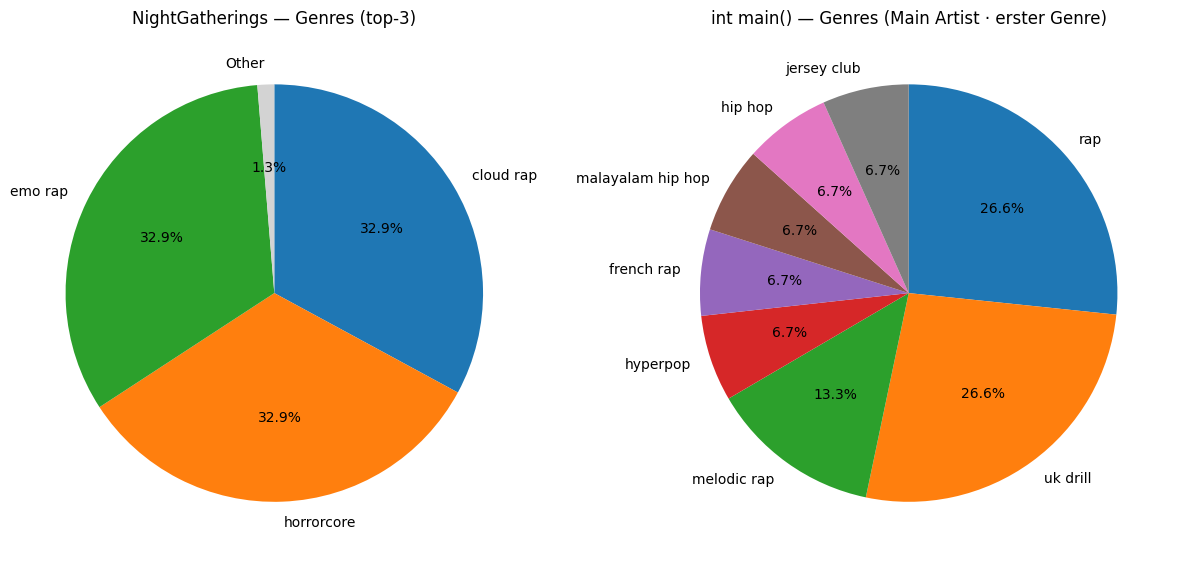

In [208]:
import matplotlib.pyplot as plt

def plot_both_pies(sp, my_tracks, oth_tracks, my_name, oth_name):
    left_df  = _prepare_pie_df_main_topk_with_threshold(sp, my_tracks, k=3, top_n=8, min_pct=3.0, other_label='Other')
    right_df = _prepare_pie_df_for_playlist(sp, oth_tracks, top_n=8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].set_title(f"{my_name} — Genres (top-3)")
    wedges, _, _ = axes[0].pie(left_df['Share (%)'], labels=left_df['Genre'], autopct='%1.1f%%', startangle=90, counterclock=False)
    for w, lbl in zip(wedges, left_df['Genre']):
        if str(lbl) == 'Other':
            w.set_facecolor('lightgray'); break

    axes[1].set_title(f"{oth_name} — Genres (Main Artist · erster Genre)")
    axes[1].pie(right_df['Share (%)'], labels=right_df['Genre'], autopct='%1.1f%%', startangle=90, counterclock=False)

    plt.tight_layout()
    plt.show()

# запуск:
plot_both_pies(sp, my_tracks, oth_tracks, my_name, oth_name)


## Schritt 4: User Story 3 - Weekly Genre Drift & Activity Digest

**User Story:** Ich will jeden Montag einen 7-Tage-Digest mit Hörstunden, Genre-Verschiebung (↑/↓ je Wochentag), neu entdeckten Artists/Alben, meistgespielten/neu gespeicherten Alben sowie kurzen, trendbasierten Vorschlägen.

**Ziel:** Wöchentliche Aktivitätsanalyse mit Genre-Trends und Entdeckungen.


In [209]:
def collect_weekly_activity_data(sp, user_id):
    """Collect weekly activity data for digest analysis"""
    if not sp:
        print("Keine Spotify-Verbindung verfügbar")
        return pd.DataFrame()
    
    print("Sammle wöchentliche Aktivitätsdaten...")
    
    try:
        # Get recent tracks for the last 7 days
        recent_tracks = sp.current_user_recently_played(limit=50)
        
        weekly_data = []
        current_date = datetime.datetime.now()
        
        for item in recent_tracks['items']:
            track = item['track']
            played_at = item['played_at']
            
            # Parse played_at timestamp
            played_datetime = datetime.datetime.fromisoformat(played_at.replace('Z', '+00:00'))
            
            # Check if track is from last 7 days
            days_diff = (current_date - played_datetime.replace(tzinfo=None)).days
            if days_diff <= 7:
                track_data = {
                    'track_id': track['id'],
                    'track_name': track['name'],
                    'artists': [artist['name'] for artist in track['artists']],
                    'artist_ids': [artist['id'] for artist in track['artists']],
                    'album_name': track['album']['name'],
                    'album_id': track['album']['id'],
                    'duration_ms': track['duration_ms'],
                    'played_at': played_at,
                    'played_datetime': played_datetime,
                    'day_of_week': played_datetime.strftime('%A'),
                    'day_of_week_num': played_datetime.weekday(),
                    'popularity': track['popularity'],
                    'explicit': track['explicit']
                }
                weekly_data.append(track_data)
        
        print(f"{len(weekly_data)} Tracks aus den letzten 7 Tagen gesammelt")
        return pd.DataFrame(weekly_data)
        
    except Exception as e:
        print(f"Fehler beim Sammeln der wöchentlichen Daten: {e}")
        return pd.DataFrame()

print("Funktion zur Sammlung wöchentlicher Aktivitätsdaten erstellt")


Funktion zur Sammlung wöchentlicher Aktivitätsdaten erstellt


In [210]:
# Collect weekly activity data
if sp:
    weekly_df = collect_weekly_activity_data(sp, user_info['id'])
    
    if not weekly_df.empty:
        print("\n=== WÖCHENTLICHE AKTIVITÄTS-DATEN ===")
        print(f"Tracks in letzter Woche: {len(weekly_df)}")
        
        # Daily activity summary
        daily_summary = weekly_df.groupby('day_of_week').agg({
            'track_id': 'count',
            'duration_ms': 'sum'
        }).rename(columns={'track_id': 'Tracks', 'duration_ms': 'Duration_ms'})
        
        daily_summary['Hours'] = (daily_summary['Duration_ms'] / (1000 * 60 * 60)).round(2)
        daily_summary['Duration_ms'] = daily_summary['Duration_ms'].astype(int)
        
        # Sort by day of week
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_summary = daily_summary.reindex([day for day in day_order if day in daily_summary.index])
        
        print("\n=== TÄGLICHE AKTIVITÄT ===")
        display(daily_summary[['Tracks', 'Hours']])
        
        # Most played tracks this week
        most_played = weekly_df['track_name'].value_counts().head(5)
        print("\n=== TOP 5 TRACKS DIESE WOCHE ===")
        most_played_df = pd.DataFrame({
            'Track': most_played.index,
            'Plays': most_played.values
        })
        display(most_played_df)
        
        # Most played artists this week
        all_artists = []
        for artists_list in weekly_df['artists']:
            all_artists.extend(artists_list)
        
        artist_counts = pd.Series(all_artists).value_counts().head(5)
        print("\n=== TOP 5 KÜNSTLER DIESE WOCHE ===")
        artist_df = pd.DataFrame({
            'Artist': artist_counts.index,
            'Plays': artist_counts.values
        })
        display(artist_df)
        
    else:
        print("Keine wöchentlichen Daten verfügbar")
        weekly_df = pd.DataFrame()
else:
    print("Spotify-Verbindung nicht verfügbar")
    weekly_df = pd.DataFrame()


Sammle wöchentliche Aktivitätsdaten...
50 Tracks aus den letzten 7 Tagen gesammelt

=== WÖCHENTLICHE AKTIVITÄTS-DATEN ===
Tracks in letzter Woche: 50

=== TÄGLICHE AKTIVITÄT ===


,Tracks,Hours
day_of_week,,
Tuesday,7,0.39
Wednesday,13,0.46
Thursday,14,0.61
Saturday,15,0.61
Sunday,1,0.03



=== TOP 5 TRACKS DIESE WOCHE ===


,Track,Plays
0,Звонок,4
1,Челси 3,2
2,ТЫ ВЫГЛЯДИШЬ,2
3,не надо,2
4,MAYBACH,2



=== TOP 5 KÜNSTLER DIESE WOCHE ===


,Artist,Plays
0,SODA LUV,11
1,THRILL PILL,8
2,uglystephan,7
3,$uicideboy$,5
4,Miyagi & Andy Panda,4


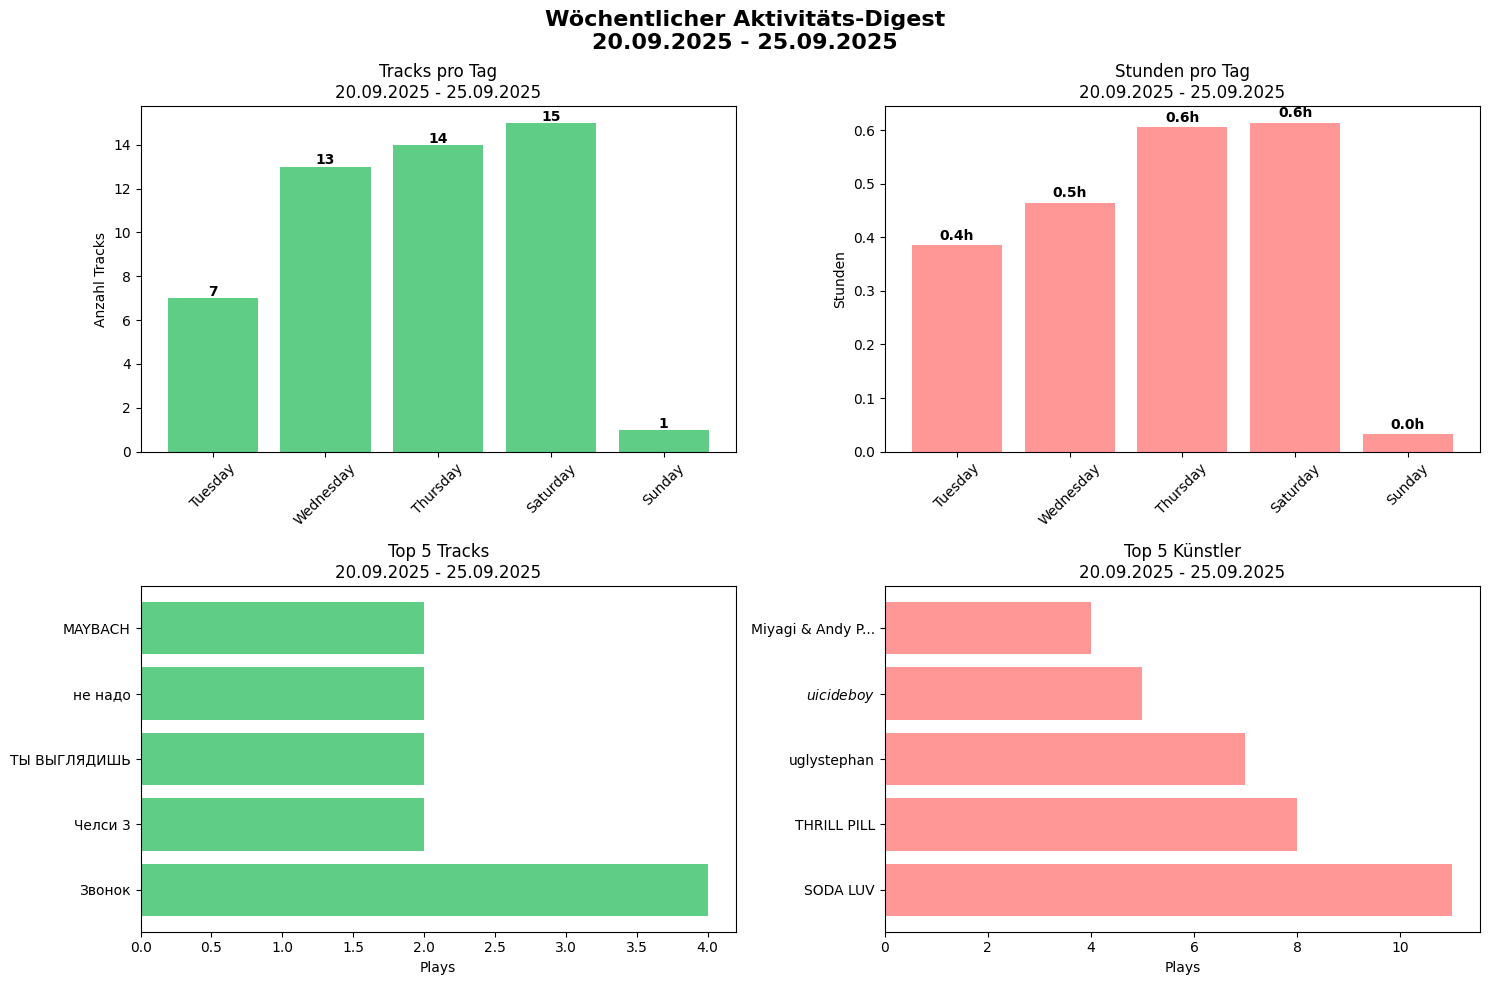


=== WÖCHENTLICHE ZUSAMMENFASSUNG (20.09.2025 - 25.09.2025) ===
Gesamte Tracks: 50
Gesamte Stunden: 2.1
Eindeutige Künstler: 22
Eindeutige Alben: 22
Durchschnitt pro Tag: 7.1 Tracks, 0.3 Stunden


In [211]:
# Weekly activity visualization
if not weekly_df.empty:
    # Calculate week date range
    min_date = weekly_df['played_datetime'].min().strftime('%d.%m.%Y')
    max_date = weekly_df['played_datetime'].max().strftime('%d.%m.%Y')
    week_range = f"{min_date} - {max_date}"
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Wöchentlicher Aktivitäts-Digest\n{week_range}', fontsize=16, fontweight='bold')
    
    # 1. Daily tracks played
    daily_tracks = weekly_df.groupby('day_of_week')['track_id'].count()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_tracks = daily_tracks.reindex([day for day in day_order if day in daily_tracks.index])
    
    axes[0, 0].bar(range(len(daily_tracks)), daily_tracks.values, color='#1DB954', alpha=0.7)
    axes[0, 0].set_title(f'Tracks pro Tag\n{week_range}')
    axes[0, 0].set_ylabel('Anzahl Tracks')
    axes[0, 0].set_xticks(range(len(daily_tracks)))
    axes[0, 0].set_xticklabels(daily_tracks.index, rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(daily_tracks.values):
        axes[0, 0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    
    # 2. Daily hours listened
    daily_hours = weekly_df.groupby('day_of_week')['duration_ms'].sum() / (1000 * 60 * 60)
    daily_hours = daily_hours.reindex([day for day in day_order if day in daily_hours.index])
    
    axes[0, 1].bar(range(len(daily_hours)), daily_hours.values, color='#FF6B6B', alpha=0.7)
    axes[0, 1].set_title(f'Stunden pro Tag\n{week_range}')
    axes[0, 1].set_ylabel('Stunden')
    axes[0, 1].set_xticks(range(len(daily_hours)))
    axes[0, 1].set_xticklabels(daily_hours.index, rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(daily_hours.values):
        axes[0, 1].text(i, v + 0.01, f'{v:.1f}h', ha='center', fontweight='bold')
    
    # 3. Most played tracks (horizontal bar)
    most_played = weekly_df['track_name'].value_counts().head(5)
    axes[1, 0].barh(range(len(most_played)), most_played.values, color='#1DB954', alpha=0.7)
    axes[1, 0].set_title(f'Top 5 Tracks\n{week_range}')
    axes[1, 0].set_xlabel('Plays')
    axes[1, 0].set_yticks(range(len(most_played)))
    axes[1, 0].set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in most_played.index])
    
    # 4. Most played artists (horizontal bar)
    all_artists = []
    for artists_list in weekly_df['artists']:
        all_artists.extend(artists_list)
    artist_counts = pd.Series(all_artists).value_counts().head(5)
    
    axes[1, 1].barh(range(len(artist_counts)), artist_counts.values, color='#FF6B6B', alpha=0.7)
    axes[1, 1].set_title(f'Top 5 Künstler\n{week_range}')
    axes[1, 1].set_xlabel('Plays')
    axes[1, 1].set_yticks(range(len(artist_counts)))
    axes[1, 1].set_yticklabels([name[:15] + '...' if len(name) > 15 else name for name in artist_counts.index])
    
    plt.tight_layout()
    plt.show()
    
    # Weekly summary
    total_tracks = len(weekly_df)
    total_hours = weekly_df['duration_ms'].sum() / (1000 * 60 * 60)
    unique_artists = len(set([artist for artists_list in weekly_df['artists'] for artist in artists_list]))
    unique_albums = weekly_df['album_name'].nunique()
    
    print(f"\n=== WÖCHENTLICHE ZUSAMMENFASSUNG ({week_range}) ===")
    print(f"Gesamte Tracks: {total_tracks}")
    print(f"Gesamte Stunden: {total_hours:.1f}")
    print(f"Eindeutige Künstler: {unique_artists}")
    print(f"Eindeutige Alben: {unique_albums}")
    print(f"Durchschnitt pro Tag: {total_tracks/7:.1f} Tracks, {total_hours/7:.1f} Stunden")
    
else:
    print("Keine Daten für wöchentliche Visualisierung verfügbar")
